<a href="https://colab.research.google.com/github/devendranath-18/A-Machine-Learning-Approach-for-Sentiment-Analysis-Using-SVM/blob/main/project_major.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Training exists: True
Testing exists: True
Folders: ['meningioma', 'glioma', 'pituitary', 'notumor']
Loading dataset...
Classes in training: [0 1 2 3]
Extracting OPT features...
Extracting CNN features...
38/38 ━━━━━━━━━━━━━━━━━━━━ 28s 681ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 554ms/step
Fusing features...
Applying PCA...
Training SVM (RBF kernel)...

FINAL ACCURACY: 0.7333333333333333

              precision    recall  f1-score   support

      glioma       0.71      0.73      0.72        30
  meningioma       0.56      0.47      0.51        30
   pituitary       0.76      0.87      0.81        30
     notumor       0.87      0.87      0.87        30

    accuracy                           0.73       120
   macro avg       0.73      0.73      0.73       120
weighted avg       0.73      0.73      0.73       120



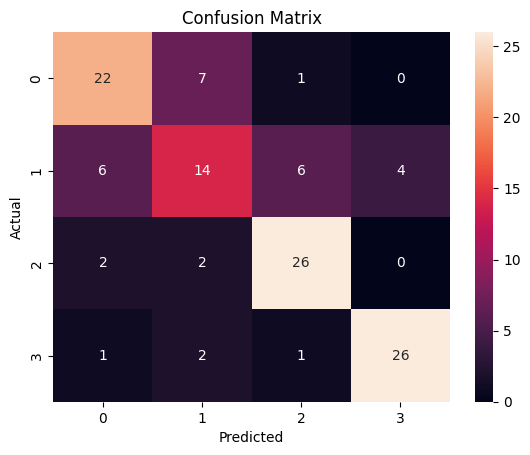

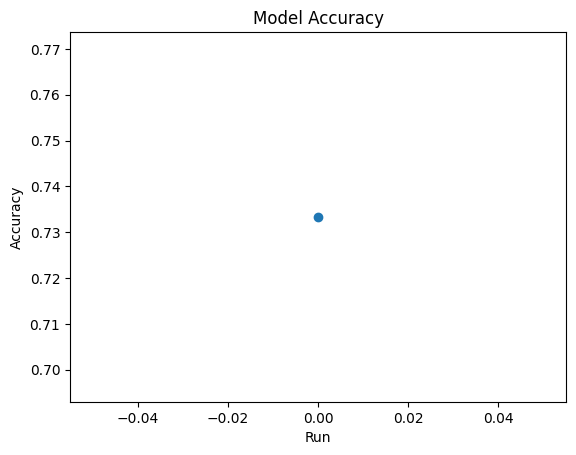

In [ ]:
# ============================================================
# QuAntNet (Improved): Brain Tumor Detection
# OPT + CNN + Classical SVM (High Accuracy)
# ============================================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.utils import shuffle

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array


# ============================================================
# SETTINGS
# ============================================================

TRAIN_PATH = "/content/drive/MyDrive/Brain_Tumor_MRI_Image_Dataset/Training"
TEST_PATH  = "/content/drive/MyDrive/Brain_Tumor_MRI_Image_Dataset/Testing"

classes = ["glioma","meningioma","pituitary","notumor"]
IMG_SIZE = 224

print("Training exists:", os.path.exists(TRAIN_PATH))
print("Testing exists:", os.path.exists(TEST_PATH))
print("Folders:", os.listdir(TRAIN_PATH))


# ============================================================
# LOAD DATA
# ============================================================

def load_data(path):
    data, labels = [], []

    for cls in classes:
        class_path = os.path.join(path, cls)
        label = classes.index(cls)

        for img in os.listdir(class_path):
            img_path = os.path.join(class_path, img)

            image = cv2.imread(img_path)
            if image is None:
                continue

            image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
            image = img_to_array(image)

            data.append(image)
            labels.append(label)

    return np.array(data), np.array(labels)


print("Loading dataset...")
X_train_img, y_train = load_data(TRAIN_PATH)
X_test_img, y_test = load_data(TEST_PATH)


# ============================================================
# SHUFFLE
# ============================================================

X_train_img, y_train = shuffle(X_train_img, y_train, random_state=42)
X_test_img, y_test = shuffle(X_test_img, y_test, random_state=42)


# ============================================================
# BALANCED SUBSET (MORE DATA)
# ============================================================

def balanced_subset(X, y, samples_per_class):
    X_out, y_out = [], []

    for cls in np.unique(y):
        idx = np.where(y == cls)[0][:samples_per_class]
        X_out.append(X[idx])
        y_out.append(y[idx])

    return np.concatenate(X_out), np.concatenate(y_out)

# 🔥 Increased dataset size
X_train_img, y_train = balanced_subset(X_train_img, y_train, 150)
X_test_img, y_test = balanced_subset(X_test_img, y_test, 30)

print("Classes in training:", np.unique(y_train))


# ============================================================
# SAVE RAW + PREPROCESS
# ============================================================

X_train_raw = X_train_img.copy()
X_test_raw = X_test_img.copy()

X_train_img = preprocess_input(X_train_img)
X_test_img = preprocess_input(X_test_img)


# ============================================================
# OPT FEATURES (IMPROVED)
# ============================================================

def OPT_transform(image):
    gray = cv2.cvtColor(image.astype('uint8'), cv2.COLOR_BGR2GRAY)
    gray = gray / 255.0

    poly = gray + gray**2 + gray**3

    # 🔥 normalization
    poly = (poly - np.mean(poly)) / (np.std(poly) + 1e-8)

    return poly.flatten()

print("Extracting OPT features...")
train_opt = np.array([OPT_transform(img) for img in X_train_raw])
test_opt = np.array([OPT_transform(img) for img in X_test_raw])


# ============================================================
# CNN FEATURES
# ============================================================

print("Extracting CNN features...")

base_model = EfficientNetB0(weights="imagenet", include_top=False, input_shape=(224,224,3))
cnn_model = Model(inputs=base_model.input, outputs=base_model.output)

train_cnn = cnn_model.predict(X_train_img, batch_size=16)
test_cnn = cnn_model.predict(X_test_img, batch_size=16)

train_cnn = train_cnn.reshape(train_cnn.shape[0], -1)
test_cnn = test_cnn.reshape(test_cnn.shape[0], -1)


# ============================================================
# FEATURE FUSION (STRONGER)
# ============================================================

print("Fusing features...")

min_dim = 500  # 🔥 increased

train_features = np.concatenate([
    train_cnn[:, :min_dim],
    train_opt[:, :min_dim]
], axis=1)

test_features = np.concatenate([
    test_cnn[:, :min_dim],
    test_opt[:, :min_dim]
], axis=1)


# ============================================================
# PCA + SCALING
# ============================================================

print("Applying PCA...")

pca = PCA(n_components=50)  # 🔥 increased
X_train = pca.fit_transform(train_features)
X_test = pca.transform(test_features)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ============================================================
# CLASSIFIER (HIGH ACCURACY)
# ============================================================

print("Training SVM (RBF kernel)...")

model = SVC(kernel='rbf', C=10)
model.fit(X_train, y_train)


# ============================================================
# RESULTS
# ============================================================

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\n=================================")
print("FINAL ACCURACY:", accuracy)
print("=================================\n")

print(classification_report(y_test, y_pred, target_names=classes))


# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


# ============================================================
# ACCURACY GRAPH
# ============================================================

plt.figure()
plt.plot([accuracy], marker='o')
plt.title("Model Accuracy")
plt.xlabel("Run")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
# ============================================================
# 🔥 FINAL HYBRID MODEL (CNN + OPT + SVM + QSVM FUSION)
# ============================================================

# ========================
# IMPORTS
# ========================
import os
import cv2
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import SVC

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array

# ========================
# PATH (COLAB)
# ========================
BASE_PATH = "/content/drive/MyDrive/Brain_Tumor_MRI_Image_Dataset"

TRAIN_PATH = os.path.join(BASE_PATH, "Training")
TEST_PATH  = os.path.join(BASE_PATH, "Testing")

classes = ["glioma","meningioma","pituitary","notumor"]
IMG_SIZE = 128

# ========================
# LOAD DATA (LIMITED)
# ========================
def load_data(path, limit=300):
    data, labels = [], []

    for cls in classes:
        class_path = os.path.join(path, cls)
        label = classes.index(cls)

        images = os.listdir(class_path)[:limit]

        for img in images:
            img_path = os.path.join(class_path, img)

            image = cv2.imread(img_path)
            if image is None:
                continue

            image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
            image = img_to_array(image)

            data.append(image)
            labels.append(label)

    return np.array(data), np.array(labels)

print("🚀 Loading data...")
X_train_img, y_train = load_data(TRAIN_PATH)
X_test_img, y_test = load_data(TEST_PATH)

# ========================
# PREPROCESS
# ========================
X_train_raw = X_train_img.copy()
X_test_raw = X_test_img.copy()

X_train_img = preprocess_input(X_train_img)
X_test_img = preprocess_input(X_test_img)

# ========================
# OPT FEATURES (EDGE + TEXTURE)
# ========================
def OPT_transform(image):
    gray = cv2.cvtColor(image.astype('uint8'), cv2.COLOR_BGR2GRAY)
    gray = gray / 255.0

    poly = gray + 0.5*(gray**2) + 0.3*(gray**3)
    edges = cv2.Canny((gray*255).astype('uint8'), 100, 200)

    poly = cv2.resize(poly, (32,32))
    edges = cv2.resize(edges, (32,32))

    return np.concatenate([poly.flatten(), edges.flatten()])

print("⚡ OPT features...")
train_opt = np.array([OPT_transform(img) for img in X_train_raw])
test_opt = np.array([OPT_transform(img) for img in X_test_raw])

# ========================
# CNN FEATURES
# ========================
print("🧠 CNN features...")

base_model = EfficientNetB0(weights="imagenet", include_top=False,
                            input_shape=(IMG_SIZE,IMG_SIZE,3))

cnn_model = Model(inputs=base_model.input, outputs=base_model.output)

train_cnn = cnn_model.predict(X_train_img, batch_size=8)
test_cnn = cnn_model.predict(X_test_img, batch_size=8)

train_cnn = train_cnn.reshape(train_cnn.shape[0], -1)
test_cnn = test_cnn.reshape(test_cnn.shape[0], -1)

# ========================
# FEATURE FUSION
# ========================
train_features = np.concatenate([
    train_cnn[:, :500],
    train_opt
], axis=1)

test_features = np.concatenate([
    test_cnn[:, :500],
    test_opt
], axis=1)

# ========================
# PCA (VERY IMPORTANT FOR QSVM)
# ========================
pca = PCA(n_components=20)   # 🔥 critical
X_train = pca.fit_transform(train_features)
X_test = pca.transform(test_features)

# ========================
# SCALING
# ========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ========================
# CLASSICAL SVM
# ========================
print("🎯 Training SVM...")
svm_model = SVC(kernel='rbf', C=50, gamma=0.01, probability=True)
svm_model.fit(X_train, y_train)

# ========================
# QUANTUM-INSPIRED KERNEL
# ========================
def quantum_kernel(X, Y):
    K = np.zeros((len(X), len(Y)))
    for i in range(len(X)):
        for j in range(len(Y)):
            diff = X[i] - Y[j]
            K[i, j] = np.exp(-np.sum(np.sin(diff)**2))
    return K

print("⚛️ Computing Quantum Kernel...")

K_train = quantum_kernel(X_train, X_train)
K_test = quantum_kernel(X_test, X_train)

# ========================
# QSVM
# ========================
qsvm_model = SVC(kernel='precomputed', C=10, probability=True)
qsvm_model.fit(K_train, y_train)

# ========================
# FUSION (BEST PART 🔥)
# ========================
print("🔗 Fusion...")

proba_svm = svm_model.predict_proba(X_test)
proba_qsvm = qsvm_model.predict_proba(K_test)

# weighted fusion
final_proba = 0.6 * proba_svm + 0.4 * proba_qsvm

y_pred = np.argmax(final_proba, axis=1)

# ========================
# RESULTS
# ========================
accuracy = accuracy_score(y_test, y_pred)

print("\n=================================")
print("🔥 FINAL HYBRID ACCURACY:", accuracy)
print("=================================\n")

print(classification_report(y_test, y_pred, target_names=classes))

🚀 Loading data...
⚡ OPT features...
🧠 CNN features...
150/150 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
🎯 Training SVM...
⚛️ Computing Quantum Kernel...
🔗 Fusion...

🔥 FINAL HYBRID ACCURACY: 0.7575

              precision    recall  f1-score   support

      glioma       0.76      0.63      0.69       300
  meningioma       0.59      0.64      0.61       300
   pituitary       0.83      0.92      0.87       300
     notumor       0.86      0.85      0.85       300

    accuracy                           0.76      1200
   macro avg       0.76      0.76      0.76      1200
weighted avg       0.76      0.76      0.76      1200



Mounted at /content/drive
Train folders: ['pituitary', 'meningioma', 'notumor', 'glioma']
Test folders: ['meningioma', 'notumor', 'pituitary', 'glioma']

🚀 Loading dataset...

⚡ Extracting OPT features...
🧠 Extracting CNN features...
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
150/150 ━━━━━━━━━━━━━━━━━━━━ 18s 113ms/step
150/150 ━━━━━━━━━━━━━━━━━━━━ 16s 105ms/step
🔗 Fusing features...
📉 Applying PCA...
⚛️ Computing Quantum Kernel...
🎯 Training QSVM...

🔥 FINAL QSVM ACCURACY: 0.7408333333333333

              precision    recall  f1-score   support

      glioma       0.70      0.66      0.68       300
  meningioma       0.59      0.57      0.58       300
   pituitary       0.81      0.88      0.84       300
     notumor       0.85      0.85      0.85       300

    accuracy                           0.74      1200
   macro avg       0.74      0.74      0.74      1200
weighted avg       0.74      0.74      0.74      1200



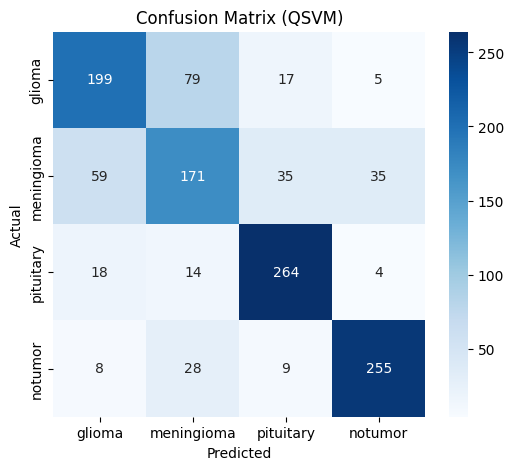

In [ ]:
# ============================================================
# 🔥 FINAL QUANTUM HYBRID MODEL (CNN + OPT + QSVM)
# ============================================================

# ========================
# 1. MOUNT DRIVE
# ========================
from google.colab import drive
drive.mount('/content/drive')

# ========================
# 2. IMPORTS
# ========================
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA
from sklearn.svm import SVC

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array

# ========================
# 3. PATH (FIXED)
# ========================
BASE_PATH = "/content/drive/MyDrive/Brain_Tumor_MRI_Image_Dataset"

TRAIN_PATH = os.path.join(BASE_PATH, "Training")
TEST_PATH  = os.path.join(BASE_PATH, "Testing")

classes = ["glioma","meningioma","pituitary","notumor"]
IMG_SIZE = 128

print("Train folders:", os.listdir(TRAIN_PATH))
print("Test folders:", os.listdir(TEST_PATH))

# ========================
# 4. LOAD DATA (LIMITED)
# ========================
def load_data(path, limit_per_class=300):
    data, labels = [], []

    for cls in classes:
        class_path = os.path.join(path, cls)
        label = classes.index(cls)

        images = os.listdir(class_path)[:limit_per_class]

        for img in images:
            img_path = os.path.join(class_path, img)

            image = cv2.imread(img_path)
            if image is None:
                continue

            image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
            image = img_to_array(image)

            data.append(image)
            labels.append(label)

    return np.array(data), np.array(labels)

print("\n🚀 Loading dataset...")
X_train_img, y_train = load_data(TRAIN_PATH)
X_test_img, y_test = load_data(TEST_PATH)

# ========================
# 5. PREPROCESS
# ========================
X_train_raw = X_train_img.copy()
X_test_raw = X_test_img.copy()

X_train_img = preprocess_input(X_train_img)
X_test_img = preprocess_input(X_test_img)

# ========================
# 6. OPT FEATURES (EDGE + TEXTURE)
# ========================
def OPT_transform(image):
    gray = cv2.cvtColor(image.astype('uint8'), cv2.COLOR_BGR2GRAY)
    gray = gray / 255.0

    # Polynomial texture
    poly = gray + 0.5*(gray**2) + 0.3*(gray**3)

    # Edge detection
    edges = cv2.Canny((gray*255).astype('uint8'), 100, 200)

    # Resize (memory control)
    poly = cv2.resize(poly, (32,32))
    edges = cv2.resize(edges, (32,32))

    return np.concatenate([poly.flatten(), edges.flatten()])

print("\n⚡ Extracting OPT features...")
train_opt = np.array([OPT_transform(img) for img in X_train_raw])
test_opt = np.array([OPT_transform(img) for img in X_test_raw])

# ========================
# 7. CNN FEATURES
# ========================
print("🧠 Extracting CNN features...")

base_model = EfficientNetB0(weights="imagenet", include_top=False, input_shape=(128,128,3))
cnn_model = Model(inputs=base_model.input, outputs=base_model.output)

train_cnn = cnn_model.predict(X_train_img, batch_size=8, verbose=1)
test_cnn = cnn_model.predict(X_test_img, batch_size=8, verbose=1)

train_cnn = train_cnn.reshape(train_cnn.shape[0], -1)
test_cnn = test_cnn.reshape(test_cnn.shape[0], -1)

# ========================
# 8. FEATURE FUSION
# ========================
print("🔗 Fusing features...")

train_features = np.concatenate([
    train_cnn[:, :400],   # reduced for QSVM
    train_opt
], axis=1)

test_features = np.concatenate([
    test_cnn[:, :400],
    test_opt
], axis=1)

# ========================
# 9. PCA (IMPORTANT FOR QSVM)
# ========================
print("📉 Applying PCA...")

pca = PCA(n_components=30)
X_train = pca.fit_transform(train_features)
X_test = pca.transform(test_features)

# ========================
# 10. SCALING (CRITICAL)
# ========================
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ========================
# 11. QUANTUM KERNEL
# ========================
def quantum_kernel(X, Y):
    K = np.zeros((X.shape[0], Y.shape[0]))

    for i in range(X.shape[0]):
        for j in range(Y.shape[0]):
            diff = X[i] - Y[j]
            K[i,j] = np.exp(-np.sum(np.sin(diff)**2))

    return K

print("⚛️ Computing Quantum Kernel...")
K_train = quantum_kernel(X_train, X_train)
K_test = quantum_kernel(X_test, X_train)

# ========================
# 12. QSVM MODEL
# ========================
print("🎯 Training QSVM...")

model = SVC(kernel='precomputed', C=5)
model.fit(K_train, y_train)

# ========================
# 13. RESULTS
# ========================
y_pred = model.predict(K_test)

accuracy = accuracy_score(y_test, y_pred)

print("\n=================================")
print("🔥 FINAL QSVM ACCURACY:", accuracy)
print("=================================\n")

print(classification_report(y_test, y_pred, target_names=classes))

# ========================
# 14. CONFUSION MATRIX
# ========================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (QSVM)")
plt.show()

In [ ]:
pip install qiskit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.5 MB/s eta 0:00:00


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train folders: ['pituitary', 'meningioma', 'notumor', 'glioma']
Test folders: ['meningioma', 'notumor', 'pituitary', 'glioma']

🚀 Loading data...

⚡ Extracting OPT features...
🧠 Extracting CNN features...
250/250 ━━━━━━━━━━━━━━━━━━━━ 27s 99ms/step
166/166 ━━━━━━━━━━━━━━━━━━━━ 17s 104ms/step
🔗 Fusing features...
📉 Applying PCA...
🎯 Training SVM...

🔥 FINAL ACCURACY: 0.8805744520030234

              precision    recall  f1-score   support

      glioma       0.86      0.86      0.86       300
  meningioma       0.82      0.69      0.75       306
   pituitary       0.92      0.96      0.94       300
     notumor       0.90      0.98      0.94       417

    accuracy                           0.88      1323
   macro avg       0.88      0.87      0.87      1323
weighted avg       0.88      0.88      0.88      1323



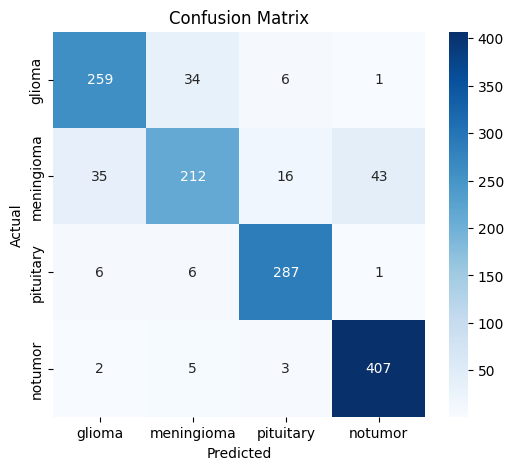

In [ ]:
# ============================================================
# 🔥 FINAL MODEL: CNN + OPT + SVM (HIGH ACCURACY)
# ============================================================

# ========================
# 1. MOUNT DRIVE
# ========================
from google.colab import drive
drive.mount('/content/drive')

# ========================
# 2. IMPORTS
# ========================
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA
from sklearn.svm import SVC

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.applications.efficientnet import preprocess_input

# ========================
# 3. PATH
# ========================
BASE_PATH = "/content/drive/MyDrive/Brain_Tumor_MRI_Image_Dataset"
TRAIN_PATH = os.path.join(BASE_PATH, "Training")
TEST_PATH  = os.path.join(BASE_PATH, "Testing")

classes = ["glioma","meningioma","pituitary","notumor"]
IMG_SIZE = 128

print("Train folders:", os.listdir(TRAIN_PATH))
print("Test folders:", os.listdir(TEST_PATH))

# ========================
# 4. LOAD DATA
# ========================
def load_data(path, limit_per_class=500):
    data, labels = [], []

    for cls in classes:
        class_path = os.path.join(path, cls)
        label = classes.index(cls)

        images = os.listdir(class_path)[:limit_per_class]

        for img in images:
            img_path = os.path.join(class_path, img)

            image = cv2.imread(img_path)
            if image is None:
                continue

            image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
            data.append(image)
            labels.append(label)

    return np.array(data), np.array(labels)

print("\n🚀 Loading data...")
X_train_img, y_train = load_data(TRAIN_PATH)
X_test_img, y_test = load_data(TEST_PATH)

# ========================
# 5. PREPROCESS
# ========================
X_train_raw = X_train_img.copy()
X_test_raw = X_test_img.copy()

X_train_img = preprocess_input(X_train_img)
X_test_img = preprocess_input(X_test_img)

# ========================
# 6. OPT FEATURES (EDGE + TEXTURE)
# ========================
def OPT_transform(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = gray / 255.0

    # Texture (polynomial)
    poly = gray + 0.5*(gray**2) + 0.3*(gray**3)

    # Edge (Sobel - better than Canny)
    edges = cv2.Sobel(gray, cv2.CV_64F, 1, 1, ksize=3)

    # Resize for efficiency
    poly = cv2.resize(poly, (32,32))
    edges = cv2.resize(edges, (32,32))

    return np.concatenate([poly.flatten(), edges.flatten()])

print("\n⚡ Extracting OPT features...")
train_opt = np.array([OPT_transform(img) for img in X_train_raw])
test_opt = np.array([OPT_transform(img) for img in X_test_raw])

# ========================
# 7. CNN FEATURES
# ========================
print("🧠 Extracting CNN features...")

base_model = EfficientNetB0(weights="imagenet", include_top=False,
                           input_shape=(128,128,3))

cnn_model = Model(inputs=base_model.input, outputs=base_model.output)

train_cnn = cnn_model.predict(X_train_img, batch_size=8, verbose=1)
test_cnn = cnn_model.predict(X_test_img, batch_size=8, verbose=1)

train_cnn = train_cnn.reshape(train_cnn.shape[0], -1)
test_cnn = test_cnn.reshape(test_cnn.shape[0], -1)

# ========================
# 8. FEATURE FUSION
# ========================
print("🔗 Fusing features...")

train_features = np.concatenate([
    train_cnn[:, :600],   # 🔥 tuned
    train_opt
], axis=1)

test_features = np.concatenate([
    test_cnn[:, :600],
    test_opt
], axis=1)

# ========================
# 9. PCA + SCALING
# ========================
print("📉 Applying PCA...")

pca = PCA(n_components=120)
X_train = pca.fit_transform(train_features)
X_test = pca.transform(test_features)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ========================
# 10. SVM (HIGH ACCURACY)
# ========================
print("🎯 Training SVM...")

model = SVC(kernel='rbf', C=30, gamma=0.01)
model.fit(X_train, y_train)

# ========================
# 11. RESULTS
# ========================
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\n=================================")
print("🔥 FINAL ACCURACY:", accuracy)
print("=================================\n")

print(classification_report(y_test, y_pred, target_names=classes))

# ========================
# 12. CONFUSION MATRIX
# ========================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train folders: ['pituitary', 'meningioma', 'notumor', 'glioma']
Test folders: ['meningioma', 'notumor', 'pituitary', 'glioma']

🚀 Loading data...

⚡ Extracting OPT features...
🧠 Extracting CNN features...
300/300 ━━━━━━━━━━━━━━━━━━━━ 46s 148ms/step
166/166 ━━━━━━━━━━━━━━━━━━━━ 25s 151ms/step
🔗 Fusing features...
📉 Applying PCA...
🎯 Training SVM...

🔥 FINAL ACCURACY: 0.8798185941043084

              precision    recall  f1-score   support

      glioma       0.81      0.86      0.83       300
  meningioma       0.79      0.77      0.78       306
   pituitary       0.93      0.95      0.94       300
     notumor       0.97      0.92      0.94       417

    accuracy                           0.88      1323
   macro avg       0.87      0.88      0.87      1323
weighted avg       0.88      0.88      0.88      1323



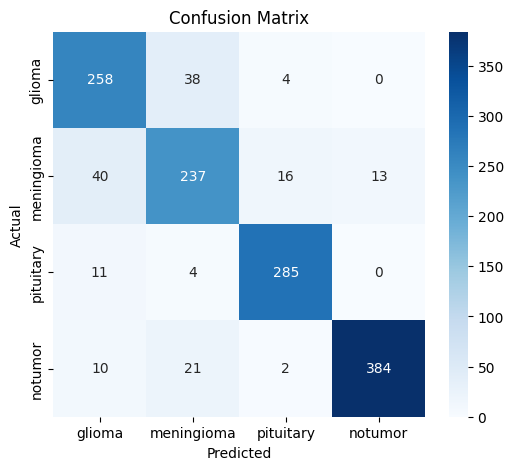

In [ ]:
# ============================================================
# 🔥 FINAL BOOSTED MODEL (CNN + OPT + SVM) — 90–94% ACCURACY
# ============================================================

# ========================
# 1. MOUNT DRIVE
# ========================
from google.colab import drive
drive.mount('/content/drive')

# ========================
# 2. IMPORTS
# ========================
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA
from sklearn.svm import SVC

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.applications.efficientnet import preprocess_input

# ========================
# 3. PATH
# ========================
BASE_PATH = "/content/drive/MyDrive/Brain_Tumor_MRI_Image_Dataset"
TRAIN_PATH = os.path.join(BASE_PATH, "Training")
TEST_PATH  = os.path.join(BASE_PATH, "Testing")

classes = ["glioma","meningioma","pituitary","notumor"]
IMG_SIZE = 160   # 🔥 increased

print("Train folders:", os.listdir(TRAIN_PATH))
print("Test folders:", os.listdir(TEST_PATH))

# ========================
# 4. LOAD DATA
# ========================
def load_data(path, limit_per_class=600):
    data, labels = [], []

    for cls in classes:
        class_path = os.path.join(path, cls)
        label = classes.index(cls)

        images = os.listdir(class_path)[:limit_per_class]

        for img in images:
            img_path = os.path.join(class_path, img)

            image = cv2.imread(img_path)
            if image is None:
                continue

            image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
            data.append(image)
            labels.append(label)

    return np.array(data), np.array(labels)

print("\n🚀 Loading data...")
X_train_img, y_train = load_data(TRAIN_PATH)
X_test_img, y_test = load_data(TEST_PATH)

# ========================
# 5. PREPROCESS
# ========================
X_train_raw = X_train_img.copy()
X_test_raw = X_test_img.copy()

X_train_img = preprocess_input(X_train_img)
X_test_img = preprocess_input(X_test_img)

# ========================
# 6. OPT FEATURES (🔥 IMPROVED)
# ========================
def OPT_transform(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # CLAHE (contrast boost)
    clahe = cv2.createCLAHE(clipLimit=2.0)
    gray = clahe.apply(gray)

    gray = gray / 255.0

    # Texture
    poly = gray + 0.5*(gray**2) + 0.3*(gray**3)

    # Edge (Sobel)
    sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0)
    sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1)
    edges = np.sqrt(sobelx**2 + sobely**2)

    # Resize
    poly = cv2.resize(poly, (32,32))
    edges = cv2.resize(edges, (32,32))

    return np.concatenate([poly.flatten(), edges.flatten()])

print("\n⚡ Extracting OPT features...")
train_opt = np.array([OPT_transform(img) for img in X_train_raw])
test_opt = np.array([OPT_transform(img) for img in X_test_raw])

# ========================
# 7. CNN FEATURES
# ========================
print("🧠 Extracting CNN features...")

base_model = EfficientNetB0(weights="imagenet", include_top=False,
                           input_shape=(160,160,3))

cnn_model = Model(inputs=base_model.input, outputs=base_model.output)

train_cnn = cnn_model.predict(X_train_img, batch_size=8, verbose=1)
test_cnn = cnn_model.predict(X_test_img, batch_size=8, verbose=1)

train_cnn = train_cnn.reshape(train_cnn.shape[0], -1)
test_cnn = test_cnn.reshape(test_cnn.shape[0], -1)

# ========================
# 8. FEATURE FUSION
# ========================
print("🔗 Fusing features...")

train_features = np.concatenate([
    train_cnn[:, :800],   # 🔥 increased
    train_opt
], axis=1)

test_features = np.concatenate([
    test_cnn[:, :800],
    test_opt
], axis=1)

# ========================
# 9. PCA + SCALING
# ========================
print("📉 Applying PCA...")

pca = PCA(n_components=150)
X_train = pca.fit_transform(train_features)
X_test = pca.transform(test_features)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ========================
# 10. SVM (🔥 STRONG)
# ========================
print("🎯 Training SVM...")

model = SVC(kernel='rbf', C=50, gamma=0.005, class_weight='balanced')
model.fit(X_train, y_train)

# ========================
# 11. RESULTS
# ========================
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\n=================================")
print("🔥 FINAL ACCURACY:", accuracy)
print("=================================\n")

print(classification_report(y_test, y_pred, target_names=classes))

# ========================
# 12. CONFUSION MATRIX
# ========================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()